# **Analyzing Impact of Teacher Attributes on Student Evaluation**

## Descriptive Statistics


In this notebook, I analyzed the impact of teacher attributes on student evaluation through descriptive statistics using Python.


### Objectives

*   Import Libraries
*   Read in Data
*   Lab exercises and questions

***


### Import Libraries


Importing the required libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Read in the csv file from the URL


In [2]:
URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/teachingratings.csv'
ratings_df=pd.read_csv(URL)
ratings_df.head()

,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof,PrimaryLast,vismin,female,single_credit,upper_division,English_speaker,tenured_prof
0,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1,0,1,1,0,1,1,1
1,yes,36,female,more,0.289916,3.7,upper,yes,yes,86,125,1,0,1,1,0,1,1,1
2,yes,36,female,more,0.289916,3.6,upper,yes,yes,76,125,1,0,1,1,0,1,1,1
3,yes,36,female,more,0.289916,4.4,upper,yes,yes,77,123,1,1,1,1,0,1,1,1
4,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2,0,0,0,0,1,1,1


## Data Description

| Variable    | Description                                                                                                                                          |
| ----------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- |
| minority    | Does the instructor belong to a minority (non-Caucasian) group?                                                                                      |
| age         | The professor's age                                                                                                                                  |
| gender      | Indicating whether the instructor was male or female.                                                                                                |
| credits     | Is the course a single-credit elective?                                                                                                              |
| beauty      | Rating of the instructor's physical appearance by a panel of six students averaged across the six panelists and standardized to have a mean of zero. |
| eval        | Course overall teaching evaluation score, on a scale of 1 (very unsatisfactory) to 5 (excellent).                                                    |
| division    | Is the course an upper or lower division course?                                                                                                     |
| native      | Is the instructor a native English speaker?                                                                                                          |
| tenure      | Is the instructor on a tenure track?                                                                                                                 |
| students    | Number of students that participated in the evaluation.                                                                                              |
| allstudents | Number of students enrolled in the course.                                                                                                           |
| prof        | Indicating instructor identifier.                                                                                                                    |


##### Displaying information about the dataset

1.  Structure of the dataframe
2.  Describe the dataset
3.  Number of rows and columns


Getting information about each variable


In [3]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   minority         463 non-null    object 
 1   age              463 non-null    int64  
 2   gender           463 non-null    object 
 3   credits          463 non-null    object 
 4   beauty           463 non-null    float64
 5   eval             463 non-null    float64
 6   division         463 non-null    object 
 7   native           463 non-null    object 
 8   tenure           463 non-null    object 
 9   students         463 non-null    int64  
 10  allstudents      463 non-null    int64  
 11  prof             463 non-null    int64  
 12  PrimaryLast      463 non-null    int64  
 13  vismin           463 non-null    int64  
 14  female           463 non-null    int64  
 15  single_credit    463 non-null    int64  
 16  upper_division   463 non-null    int64  
 17  English_speaker 

In [4]:
ratings_df.shape

(463, 19)

#### Identifying whether the teachers' Rating data is a time series or cross-sectional


No, it is not a time series dataset because it does not have a date or time variable

It is cross-sectional dataset because it observe more than one teacher being rated


In [5]:
ratings_df.head(10)

,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof,PrimaryLast,vismin,female,single_credit,upper_division,English_speaker,tenured_prof
0,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1,0,1,1,0,1,1,1
1,yes,36,female,more,0.289916,3.7,upper,yes,yes,86,125,1,0,1,1,0,1,1,1
2,yes,36,female,more,0.289916,3.6,upper,yes,yes,76,125,1,0,1,1,0,1,1,1
3,yes,36,female,more,0.289916,4.4,upper,yes,yes,77,123,1,1,1,1,0,1,1,1
4,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2,0,0,0,0,1,1,1
5,no,59,male,more,-0.737732,4.0,upper,yes,yes,35,40,2,0,0,0,0,1,1,1
6,no,59,male,more,-0.737732,2.1,upper,yes,yes,39,44,2,1,0,0,0,1,1,1
7,no,51,male,more,-0.571984,3.7,upper,yes,yes,55,55,3,0,0,0,0,1,1,1
8,no,51,male,more,-0.571984,3.2,upper,yes,yes,111,195,3,1,0,0,0,1,1,1
9,no,40,female,more,-0.677963,4.3,upper,yes,yes,40,46,4,0,0,1,0,1,1,1


#### Finding the mean, median, minimum, and maximum values for students


Mean value for students


In [6]:
round(ratings_df['students'].mean(), 2)

np.float64(36.62)

Median value for students


In [7]:
ratings_df['students'].median()

np.float64(23.0)

Minimum value for students


In [8]:
ratings_df['students'].min()

np.int64(5)

Maximum value for students


In [9]:
ratings_df['students'].max()

np.int64(380)

Creating a descriptive statistics table


In [10]:
ratings_df.describe()

,age,beauty,eval,students,allstudents,prof,PrimaryLast,vismin,female,single_credit,upper_division,English_speaker,tenured_prof
count,463.000000,4.630000e+02,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000
mean,48.365011,6.271140e-08,3.998272,36.624190,55.177106,45.434125,0.203024,0.138229,0.421166,0.058315,0.660907,0.939525,0.779698
std,9.802742,7.886477e-01,0.554866,45.018481,75.072800,27.508902,0.402685,0.345513,0.494280,0.234592,0.473913,0.238623,0.414899
min,29.000000,-1.450494e+00,2.100000,5.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,-6.562689e-01,3.600000,15.000000,19.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,48.000000,-6.801430e-02,4.000000,23.000000,29.000000,44.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,57.000000,5.456024e-01,4.400000,40.000000,60.000000,70.500000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,73.000000,1.970023e+00,5.000000,380.000000,581.000000,94.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Creating a histogram of the beauty variable

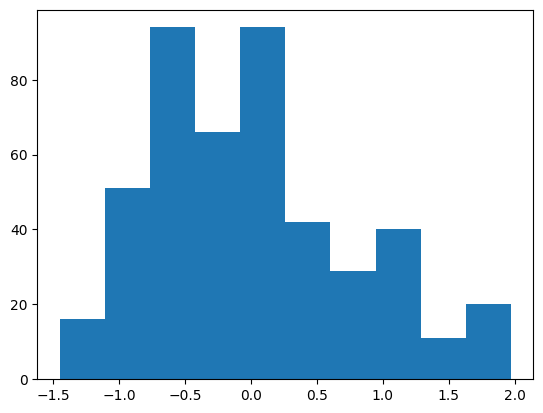

In [11]:
plt.hist(ratings_df['beauty'])
plt.show()

#### Analysis:

- Most of the data for beauty is around the -0.5 and 0
- The distribution is skewed to the right
- Therefore, looking at the data, I can say that the mean is close to 0


#### Does average beauty score differ by gender? 

Calculating the means and standard deviations for both male and female instructors.


Using a group by gender to view the mean scores of the beauty

In [12]:
ratings_df.groupby('gender').agg({'beauty':['mean', 'std', 'var']}).reset_index()

gender    beauty                   
               mean      std       var
0  female  0.116109  0.81781  0.668813
1    male -0.084482  0.75713  0.573246

#### Analysis:

- Female instructors have a higher average beauty score compared to male instructors, suggesting a slight gender difference in perceived beauty ratings.


#### Does tenure status differ by gender? 

Calculating the percentage of males and females that are tenured professors.


First groupby to get the total sum and then finding the percentage of each gender


In [13]:
tenure_count = ratings_df[ratings_df.tenure == 'yes'].groupby('gender').agg({'tenure': 'count'}).reset_index()
tenure_count['percentage'] = 100 * tenure_count.tenure/tenure_count.tenure.sum()
tenure_count

,gender,tenure,percentage
0,female,145,40.166205
1,male,216,59.833795


#### Analysis:

- Tenure status does differ by gender as the percentage of males (60%) that are tenured professors is higher than females (40%).

#### Does tenure status differ if teacher was a visible minority?

Calculating the percentage of visible minorities that are tenure professors. 


First filtering for the tenured Professors

In [14]:
ratings_df_yes = ratings_df[ratings_df['tenure']=='yes']
ratings_df_no = ratings_df[ratings_df['tenure']=='no']

Groupby to get the total sum and then finding the percentage

In [15]:
tenure_count = ratings_df_yes.groupby('minority').agg({'tenure': 'count'}).reset_index()
tenure_count['percentage'] = 100 * tenure_count.tenure/tenure_count.tenure.sum()
tenure_count

,minority,tenure,percentage
0,no,307,85.041551
1,yes,54,14.958449


In [16]:
tenure_count = ratings_df_no.groupby('minority').agg({'tenure': 'count'}).reset_index()
tenure_count['percentage'] = 100 * tenure_count.tenure/tenure_count.tenure.sum()
tenure_count

,minority,tenure,percentage
0,no,92,90.196078
1,yes,10,9.803922


In [17]:
minority_count = ratings_df.groupby('tenure').agg({'minority': 'count'}).reset_index()
minority_count['percentage'] = 100 * minority_count.minority/minority_count.minority.sum()
minority_count

,tenure,minority,percentage
0,no,102,22.030238
1,yes,361,77.969762


In [18]:
%pip install -qqq datascience
from datascience import *
rating_tb = Table().read_table('TeachingRatings.csv')
rating_tb.group(['tenure', 'minority'])

Note: you may need to restart the kernel to use updated packages.


tenure,minority,count
no,no,92
no,yes,10
yes,no,307
yes,yes,54


#### Analysis:

- Among tenure professors, 85% are non-minorities and only 15% are visible minorities, even though visible minorities make up about 22% of all faculty.
- For non-tenure professors, about 90% are non-minorities and 10% are minorities, showing visible minorities have slightly less representation in non-tenure roles compared to tenure.
- Overall, 78% of all professors are tenure holders (361) and 22% non tenure holders (102), and within this tenure group, visible minorities hold a noticeably smaller share compared to non-minorities, suggesting tenure status differs by minority status.

- The data suggests visible minorities are less likely to hold tenured positions compared to their non-minority peers.


#### Does average age differ by tenure? 

Calculating the means and standard deviations for both tenured and untenured professors.


In [19]:
ratings_df["tenure"].value_counts()

tenure
yes    361
no     102
Name: count, dtype: int64

In [20]:
ratings_df.groupby('tenure').agg({'age':['mean', 'std']}).round(2)

age       
         mean    std
tenure              
no      50.19   6.95
yes     47.85  10.42

#### Analysis:

- Untenured professors have a higher average age (50.19) compared to tenured professors (47.85). This is somewhat unexpected, since we often assume tenured professors would be older due to career progression.
- Standard deviation is higher for tenured faculty (10.42) than for untenured ones (6.95), suggesting more variability in age among those with tenure.
- This means some tenured professors are quite young while others are older.
- Yes, average age does differ, but not drastically.

Creating a histogram for the age variable.


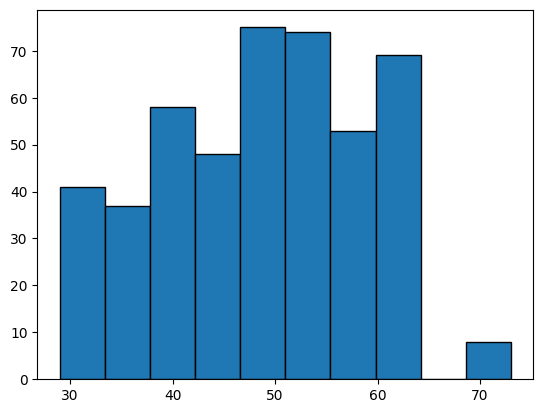

In [29]:
plt.hist(ratings_df['age'])
plt.show();

Creating a bar plot for the gender variable.


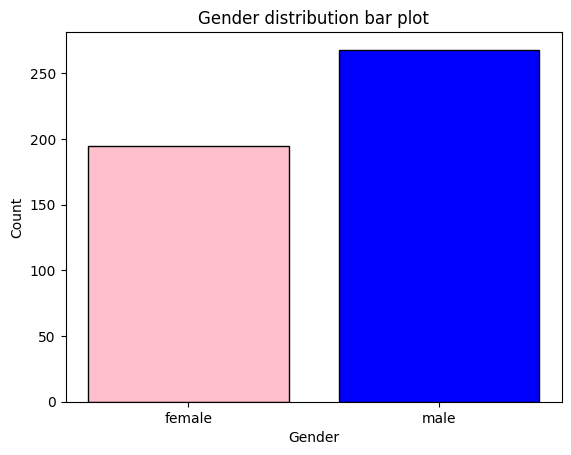

In [28]:
# Sorting the value counts by index to align with the unique gender labels
sorted_counts = ratings_df.gender.value_counts().sort_index()

# Creating the bar plot with sorted values
plt.bar(sorted_counts.index, sorted_counts.values, color=['pink', 'blue'])

# Adding labels and title
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender distribution bar plot')
plt.show();

Calculating the Median evaluation score for tenured Professors


In [30]:
ratings_df[ratings_df['tenure'] == 'yes']['eval'].median()

4.0

---

### Authors

- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b/)